# Approche A — Pipeline Intégré (ImbPipeline)

## Méthodologie
Ce notebook utilise `imblearn.pipeline.Pipeline` (ImbPipeline) pour encapsuler **toute** la chaîne de prétraitement (Imputation → Scaling → SMOTE → Modèle) dans un seul objet.

**Avantage principal** : Lors de la validation croisée, SMOTE est appliqué **uniquement sur les plis d'entraînement** à chaque itération, ce qui **empêche toute fuite de données** (data leakage).

### Les 4 modèles comparés :
1. **Decision Tree** — Modèle de base, interprétable
2. **Random Forest** — Ensemble de bagging, réduit le sur-apprentissage
3. **AdaBoost** — Ensemble de boosting, focus sur les erreurs
4. **Neural Network (MLP)** — Modèle non-linéaire profond

### Métriques privilégiées (données déséquilibrées) :
- **Recall** (Sensibilité) : Capacité à détecter les défauts → prioritaire en industrie
- **AUC** (Area Under ROC Curve) : Performance globale du classifieur
- **F1-Score** : Équilibre entre précision et rappel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, recall_score, f1_score,
                             roc_auc_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Les 4 modèles demandés (Section 3.3)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid")

# ── 1. Chargement ──
data = pd.read_csv("uci-secom.csv")

# ── 2. Nettoyage initial ──
cols_to_drop = [c for c in ['Time', 'Phase'] if c in data.columns]
data = data.drop(columns=cols_to_drop)

X = data.drop(columns=['Pass/Fail'])
y = data['Pass/Fail'].replace({-1: 0})  # 0 = Bon, 1 = Défaut

# ── 3. SPLIT stratifié (70/30) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train Set : {X_train.shape}")
print(f"Test Set  : {X_test.shape}")
print(f"Ratio défauts (Train) : {y_train.mean():.2%}")
print(f"Ratio défauts (Test)  : {y_test.mean():.2%}")

Train Set : (1096, 590)
Test Set  : (471, 590)
Ratio défauts (Train) : 6.66%
Ratio défauts (Test)  : 6.58%


## Analyse Exploratoire (EDA)

Avant de modéliser, on vérifie :
- Le **déséquilibre des classes** (justifie l'usage de SMOTE)
- Le **taux de valeurs manquantes** (justifie l'imputation par médiane)
- La **forme des données** (591 features pour ~1567 échantillons)

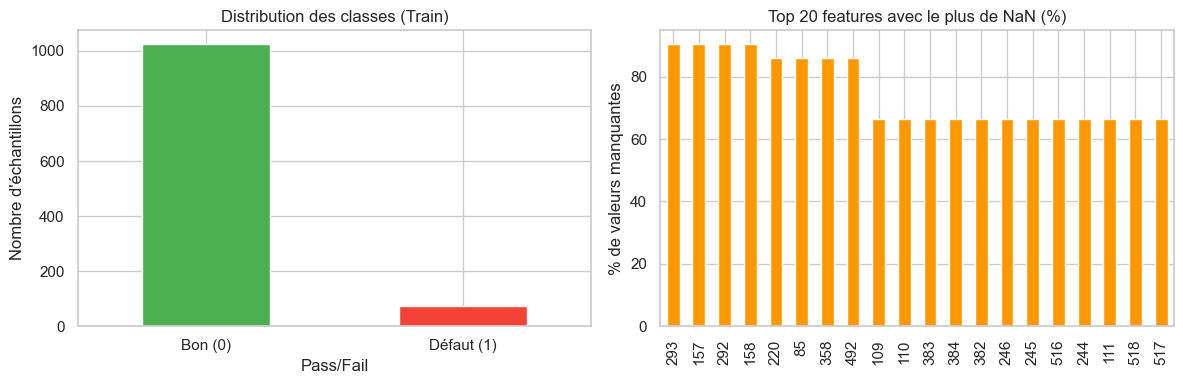

Classe 0 (Bon)    : 1023 (93.3%)
Classe 1 (Défaut) : 73 (6.7%)
Ratio d'imbalance : 1:14

Features avec >50% NaN : 24
Features avec >0% NaN  : 462


In [2]:
# ── EDA : Déséquilibre des classes ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
y_train.value_counts().plot.bar(ax=axes[0], color=['#4CAF50', '#F44336'])
axes[0].set_title("Distribution des classes (Train)")
axes[0].set_xticklabels(['Bon (0)', 'Défaut (1)'], rotation=0)
axes[0].set_ylabel("Nombre d'échantillons")

# Pourcentage de NaN par feature (top 20)
nan_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
nan_pct.head(20).plot.bar(ax=axes[1], color='#FF9800')
axes[1].set_title("Top 20 features avec le plus de NaN (%)")
axes[1].set_ylabel("% de valeurs manquantes")

plt.tight_layout()
plt.show()

print(f"Classe 0 (Bon)    : {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"Classe 1 (Défaut) : {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")
print(f"Ratio d'imbalance : 1:{(y_train == 0).sum() // max((y_train == 1).sum(), 1)}")
print(f"\nFeatures avec >50% NaN : {(nan_pct > 50).sum()}")
print(f"Features avec >0% NaN  : {(nan_pct > 0).sum()}")

## Validation Croisée Stratifiée (5-Fold)

**Pourquoi ImbPipeline ?** Avec `cross_val_score` classique + SMOTE appliqué avant, les données synthétiques SMOTE peuvent fuiter dans les plis de validation. L'ImbPipeline garantit que SMOTE est ré-appliqué **uniquement sur le pli d'entraînement** à chaque itération.

**Optimisation** : On utilise `cross_validate` avec plusieurs métriques simultanément au lieu d'appeler `cross_val_score` 3 fois (ce qui triplerait le temps de calcul).

In [ ]:
# Définition des modèles (Section 3.3)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

# Validation Croisée Stratifiée (5 plis)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'auc': 'roc_auc', 'recall': 'recall', 'f1': 'f1'}

print(f"{'MODÈLE':<20} | {'AUC (CV)':<12} | {'RECALL (CV)':<12} | {'F1 (CV)':<12}")
print("-" * 65)

results = {}

for name, model in models.items():
    # Pipeline complet : Impute → Scale → SMOTE → Classifier
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # cross_validate calcule TOUTES les métriques en un seul passage (5 fits au lieu de 15)
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    
    auc_mean = cv_results['test_auc'].mean()
    rec_mean = cv_results['test_recall'].mean()
    f1_mean  = cv_results['test_f1'].mean()
    
    results[name] = {
        'pipeline': pipeline,
        'auc': auc_mean,
        'recall': rec_mean,
        'f1': f1_mean,
        'auc_std': cv_results['test_auc'].std(),
        'recall_std': cv_results['test_recall'].std(),
        'f1_std': cv_results['test_f1'].std()
    }
    
    print(f"{name:<20} | {auc_mean:.4f}±{cv_results['test_auc'].std():.3f} | "
          f"{rec_mean:.4f}±{cv_results['test_recall'].std():.3f} | "
          f"{f1_mean:.4f}±{cv_results['test_f1'].std():.3f}")

# Tableau récapitulatif
print("\n── Classement par AUC (CV) ──")
for rank, (name, res) in enumerate(
    sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True), 1):
    print(f"  {rank}. {name:<20} AUC={res['auc']:.4f}  Recall={res['recall']:.4f}")

MODÈLE               | AUC (CV)     | RECALL (CV)  | F1 (CV)     
-----------------------------------------------------------------
Decision Tree        | 0.5361±0.028 | 0.1914±0.049 | 0.1355±0.039
Random Forest        | 0.6503±0.073 | 0.0133±0.027 | 0.0235±0.047


c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\E N V Y\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost             | 0.6049±0.043 | 0.2467±0.054 | 0.1691±0.030
Neural Network       | 0.6288±0.045 | 0.0800±0.065 | 0.1045±0.085

── Classement par AUC (CV) ──
  1. Random Forest        AUC=0.6503  Recall=0.0133
  2. Neural Network       AUC=0.6288  Recall=0.0800
  3. AdaBoost             AUC=0.6049  Recall=0.2467
  4. Decision Tree        AUC=0.5361  Recall=0.1914


## Évaluation Finale sur le Test Set

On ré-entraîne chaque pipeline sur **tout** le `X_train` puis on évalue sur `X_test` (données jamais vues).

**Pourquoi re-entraîner ?** La CV ne produit pas un modèle final — elle mesure la robustesse. Le modèle final utilise 100% du train set.

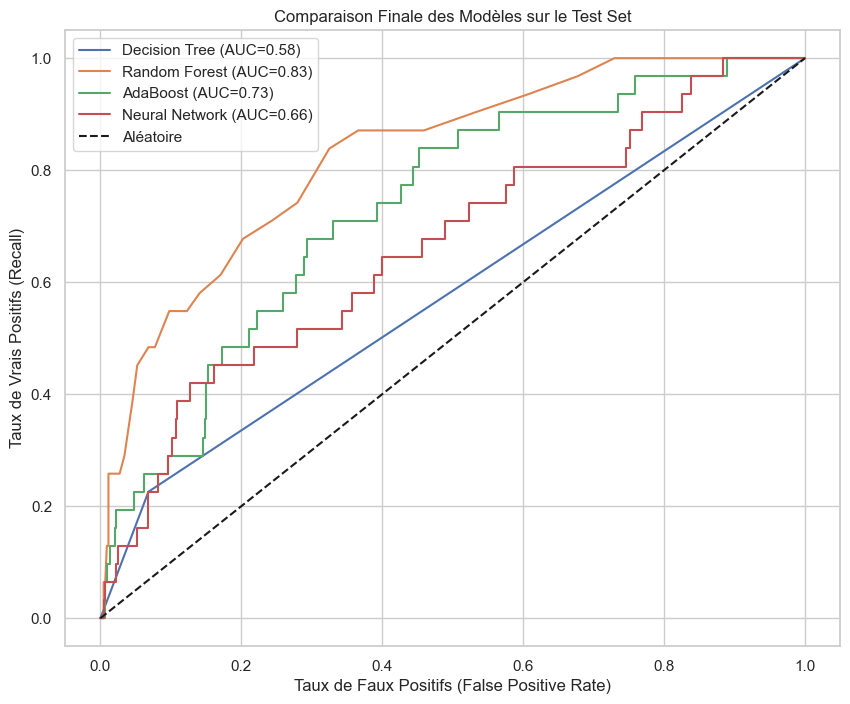

In [ ]:
plt.figure(figsize=(10, 8))

for name, res in results.items():
    pipeline = res['pipeline']
    
    # Entraînement final sur tout le Train Set
    pipeline.fit(X_train, y_train)
    
    # Prédictions sur le Test Set (jamais vu pendant l'entraînement)
    y_pred = pipeline.predict(X_test)
    
    if hasattr(pipeline['classifier'], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipeline.predict(X_test).astype(float)
    
    # Métriques sur le Test
    test_auc = roc_auc_score(y_test, y_prob)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    
    res['test_auc'] = test_auc
    res['test_recall'] = test_recall
    res['test_f1'] = test_f1
    res['y_pred'] = y_pred
    res['y_prob'] = y_prob
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={test_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (Recall / TPR)')
plt.title('Courbes ROC — Comparaison Finale sur le Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Tableau récapitulatif Test ──
print(f"\n{'MODÈLE':<20} | {'AUC (Test)':<12} | {'RECALL (Test)':<14} | {'F1 (Test)':<12}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<20} | {res['test_auc']:<12.4f} | {res['test_recall']:<14.4f} | {res['test_f1']:<12.4f}")

# ── Sélection automatique du meilleur modèle ──
best_name = max(results, key=lambda k: results[k]['test_auc'])
print(f"\n★ Meilleur modèle (par AUC Test) : {best_name} — AUC={results[best_name]['test_auc']:.4f}")

## Résultats Détaillés par Modèle

Pour chaque modèle : **Classification Report** + **Matrice de Confusion**.

--- RÉSULTATS DÉTAILLÉS : Neural Network ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       440
           1       0.22      0.13      0.16        31

    accuracy                           0.91       471
   macro avg       0.58      0.55      0.56       471
weighted avg       0.89      0.91      0.90       471



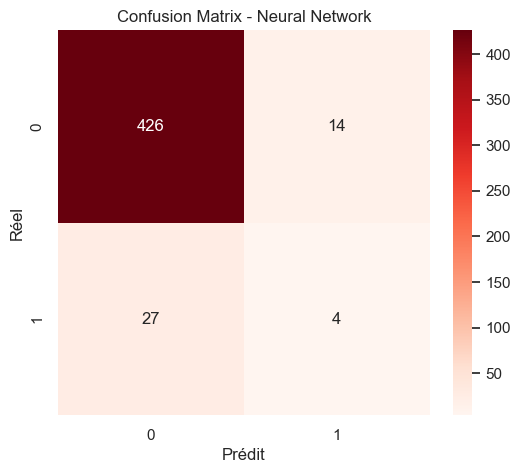

In [ ]:
# Matrice de confusion + Classification report pour CHAQUE modèle
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    y_pred = res['y_pred']
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx],
                annot_kws={"size": 14})
    axes[idx].set_title(f"{name}\nAUC={res['test_auc']:.2f} | Recall={res['test_recall']:.2f}")
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

plt.suptitle("Matrices de Confusion — Tous les Modèles", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Optimisation du Seuil de Décision

Par défaut, le seuil de classification est 0.5. En contexte industriel (détection de défauts), on peut **baisser le seuil** pour augmenter le Recall (détecter plus de défauts) au prix d'un peu plus de faux positifs.

On utilise la courbe **Precision-Recall** pour trouver le seuil optimal.

In [ ]:
# Optimisation du seuil pour chaque modèle (objectif : Recall ≥ 85%)
target_recall = 0.85

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    y_prob = res['y_prob']
    
    # Courbe Precision-Recall
    precision, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
    
    # Trouver le seuil qui garantit le Recall cible
    valid_idx = np.where(recall_vals >= target_recall)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[-1]
        best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    else:
        best_thresh = 0.5  # Fallback
    
    # Prédictions avec seuil optimisé
    y_pred_opt = (y_prob >= best_thresh).astype(int)
    
    opt_recall = recall_score(y_test, y_pred_opt)
    opt_f1 = f1_score(y_test, y_pred_opt)
    
    print(f"{name:<20} | Seuil optimal : {best_thresh:.4f} | Recall : {opt_recall:.2%} | F1 : {opt_f1:.4f}")
    
    # Matrice optimisée
    cm = confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                annot_kws={"size": 14})
    axes[idx].set_title(f"{name}\nSeuil={best_thresh:.2f} | Recall={opt_recall:.0%}")
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

plt.suptitle(f"Matrices de Confusion Optimisées (Objectif Recall ≥ {target_recall:.0%})",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Synthèse Finale

Tableau comparatif complet : performances en **validation croisée** vs **test set**.

In [ ]:
# ── Tableau de synthèse ──
summary = pd.DataFrame({
    'AUC (CV)': {n: f"{r['auc']:.4f}±{r['auc_std']:.3f}" for n, r in results.items()},
    'Recall (CV)': {n: f"{r['recall']:.4f}±{r['recall_std']:.3f}" for n, r in results.items()},
    'F1 (CV)': {n: f"{r['f1']:.4f}±{r['f1_std']:.3f}" for n, r in results.items()},
    'AUC (Test)': {n: f"{r['test_auc']:.4f}" for n, r in results.items()},
    'Recall (Test)': {n: f"{r['test_recall']:.4f}" for n, r in results.items()},
    'F1 (Test)': {n: f"{r['test_f1']:.4f}" for n, r in results.items()},
})

print("╔══════════════════════════════════════════════════════════════════════╗")
print("║               SYNTHÈSE APPROCHE A (ImbPipeline)                    ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print(summary.to_string())

best = max(results, key=lambda k: results[k]['test_auc'])
print(f"\n★ MEILLEUR MODÈLE : {best}")
print(f"  → AUC Test  = {results[best]['test_auc']:.4f}")
print(f"  → Recall Test = {results[best]['test_recall']:.4f}")
print(f"  → F1 Test   = {results[best]['test_f1']:.4f}")